<a href="https://colab.research.google.com/github/a-mensah26/Lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Akosua Twumwaa Boateng - Mensah
**Student ID:** 66942028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)


Running on: cpu


In [2]:
#!git config --global user.email "akosua.mensah@ashesi.edu.gh"
#!git config --global user.name "a-mensah26"

In [3]:
#!git clone https://github.com/a-mensah26/Lab-3.git

In [4]:
#%cd Lab-3
#!git add .
#!git commit -m "1st Commit"
#!git push origin main

---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

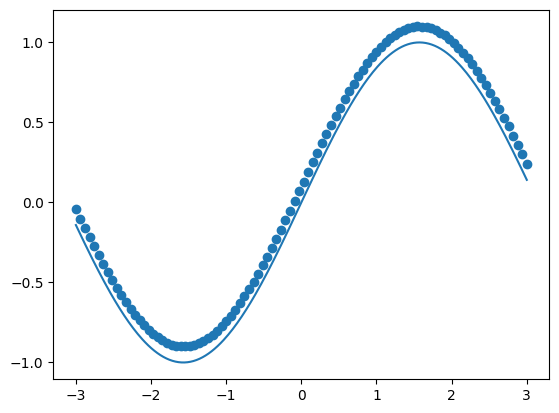

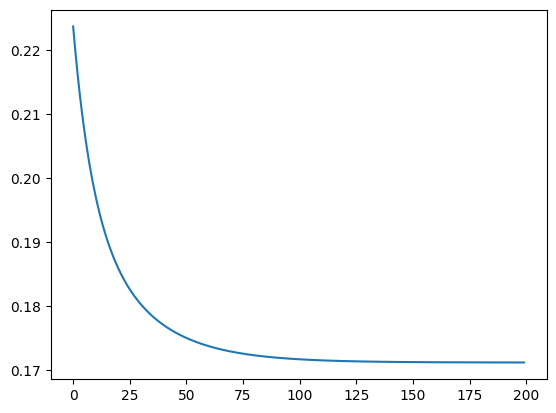

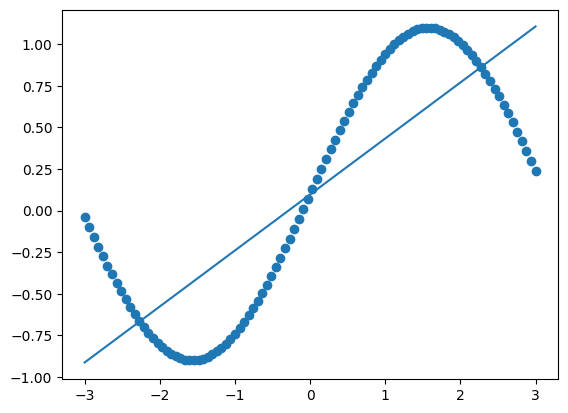

In [5]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100);
std= 0.1  #small Gaussian noise
y = np.sin(x) + std;
#   Plot it.
plot_x = np.linspace(-3, 3, 300)
plot_y = np.sin(plot_x)
plt.plot(plot_x, plot_y, label="true sin(x)")
plt.scatter(x, y)
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn()*0.5
b = np.random.randn()*0.5
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:

lr = 0.01
n_steps = 200
losses = []


for i in range(n_steps):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)               # MSE
  dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
  db    = np.mean(2 * (y_hat - y))                # dLoss/db
  w    -= lr * dw
  b    -= lr * db
  losses.append(loss)
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
plt.plot(losses)
plt.show()
#(b) the data with the fitted line on top.
plt.scatter(x, y, label='Data')
plt.plot(plot_x, w * plot_x + b)
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
1.
2. This is underfitting.
A single neuron can only compute y = wx + b (a linear function). No matter how long it is trained the output would always be linear and never a curve.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

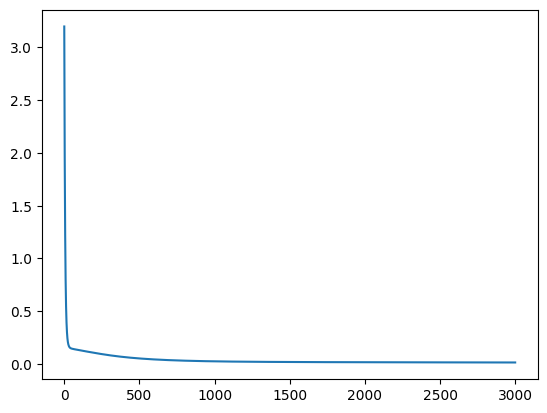

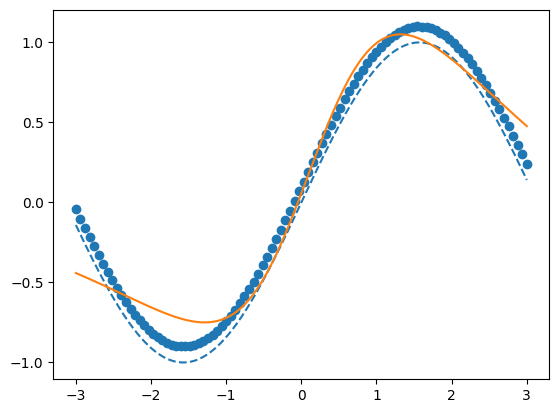

In [6]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
#   W2: shape (8, 1),  b2: shape (1,)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5
#   Small random values (e.g. np.random.randn(...) * 0.5)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr = 0.01
loop = 3000
losses = []
for i in range(loop):
  z1 = x @ W1 + b1
  h  = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y) ** 2)
  losses.append(loss)


  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat ;
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1 ;
  db1 = dz1.sum(axis=0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2
# TODO: Plot the loss curve AND the final fit over the data.
plot_x = np.linspace(-3, 3, 300).reshape(-1, 1)
z1_plot = plot_x @ W1 + b1
h_plot = np.tanh(z1_plot)
y_plot = h_plot @ W2 + b2
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.plot(losses)
plt.show()
plt.plot(plot_x, np.sin(plot_x), label='true sin(x)', linestyle='--')
plt.plot(plot_x, y_plot, label='network fit')
plt.scatter(x, y, label='Data')
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. Stacking layers without non - linearity is just a linear function with the combined weights and bias. The linear function y = (w1w2)x + (w2b1 + b2). Regardless of the number of layers stacked the output is always linear.


2.

3. Backpropagation is continuously applying the chain rule backward through the network to compute the gradient with repect to every weight and bias.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

lr=0.001, step=0, loss=0.8628922836608776
lr=0.001, step=1, loss=0.8537946624547665
lr=0.001, step=2, loss=0.8448052889702663
lr=0.001, step=3, loss=0.8359228037948925
lr=0.001, step=4, loss=0.8271458673422784
lr=0.001, step=500, loss=0.09719042969485217
lr=0.001, step=1000, loss=0.08569360074611523
lr=0.001, step=1500, loss=0.07602026232560903
lr=0.001, step=2000, loss=0.06733177936101624
lr=0.001, step=2500, loss=0.05976335762282642
lr=0.05, step=0, loss=0.5292259654725723
lr=0.05, step=1, loss=0.17129599502832904
lr=0.05, step=2, loss=0.1391464258950832
lr=0.05, step=3, loss=0.13324229573370666
lr=0.05, step=4, loss=0.13038838215747922
lr=0.05, step=500, loss=0.008430233125269287
lr=0.05, step=1000, loss=0.006454249021707039
lr=0.05, step=1500, loss=0.00494771127914778
lr=0.05, step=2000, loss=0.003754439576158035
lr=0.05, step=2500, loss=0.0028306840487596504
lr=1.0, step=0, loss=0.32331116711860675
lr=1.0, step=1, loss=2.0251537810495104
lr=1.0, step=2, loss=0.5840558704712404
lr=

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1099/3324015625.py:13: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_1099/3324015625.py:22: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_1099/3324015625.py:23: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


lr=1.0, step=1000, loss=nan
lr=1.0, step=1500, loss=nan
lr=1.0, step=2000, loss=nan
lr=1.0, step=2500, loss=nan


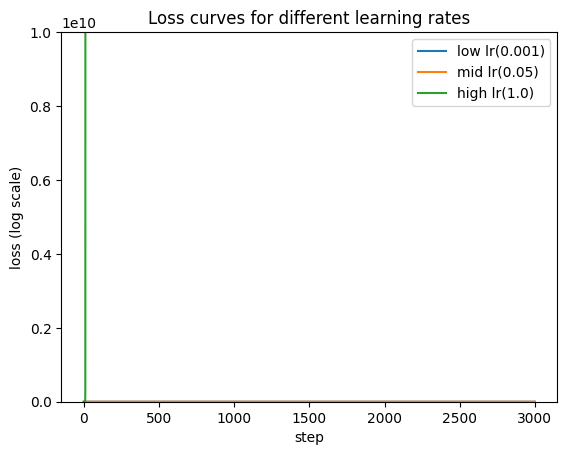

In [7]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.random.randn(1) * 0.5
  losses = []
  for i in range(loop):
    z1 = x @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)
    if i < 5 or i % 500 == 0:
      print(f"lr={lr}, step={i}, loss={loss}")


    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat ;
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1 ;
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
low_losses = train_toy(0.001)
mid_losses = train_toy(0.05)
high_losses = train_toy(1.0)
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.plot(low_losses, label='low lr(0.001)')
plt.plot(mid_losses, label='mid lr(0.05)')
plt.plot(high_losses, label='high lr(1.0)')
plt.xlabel('step')
plt.ylabel('loss (log scale)')
plt.ylim(1e-4, 1e10)
plt.legend()
plt.title('Loss curves for different learning rates')
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** lr = 0.001 => the loss descreases slowly and doesnt converge within the 3000 steps.

lr = 0.05 => the loss drops smoothly to a low, stable value.

lr = 1.0 => the loss explodes instead instead of decreasing.

When the learning rate is too large the gradient step overshoots the minimum of the loss surface. The update moves past the lower loss to a point with a higher loss. the next step overshoots and causes divergence.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
obesity = pd.read_csv(OBESITY_URL)
obesity.nunique()
obesity["BMI"] = obesity['Weight'] / obesity['Height'] ** 2


cat_cols1 = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})
obesity['Gender'] = obesity['Gender'].map({'Male': 1, 'Female': 0})
ordinal_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(ordinal_map)
obesity['CALC'] = obesity['CALC'].map(ordinal_map)

obesity = pd.get_dummies(obesity, columns=['MTRANS'], drop_first=False)

lab_en = LabelEncoder()
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop('NObeyesdad', axis=1)
y = lab_en.fit_transform(obesity['NObeyesdad'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_test)


# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# TODO: Convert to tensors and wrap in DataLoaders:
x_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
x_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
x_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=32, shuffle=False)

print(x_train_t.shape, y_train_t.shape)

torch.Size([1266, 21]) torch.Size([1266])


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**
1.

2. Neural networks update weights using gradients proportional to the input magnitude. The feature with much larger scale produces disproportionately large gradients.

3. shuffle=True randomizes samples which are grouped into each epoch, so the model does not repeatedly see batches in fixed order. This makes gradient estimates be more representitive of the epoch.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [9]:
from itertools import count
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
  #def __init__(self, ...):
  def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
    super(FeedForwardNet, self).__init__()
    self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
    self.relu1 = nn.ReLU()
    self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
    self.relu2 = nn.ReLU()
    self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
  #def forward(self, x):
  def forward(self, x):
    x = self.fc1(x)
    x = self.relu1(x)
    x = self.fc2(x)
    x = self.relu2(x)
    x = self.fc3(x)
    return x

# TODO: Instantiate, move to DEVICE, print the model.
model = FeedForwardNet(input_dim=x_train_t.shape[1], hidden_sizes=(64, 32), n_classes=7)
model.to(DEVICE)
print(model)
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
first_layer= x_train_t.shape[1] * 64 + 64
print(f"Count for the first layer: {first_layer}")

FeedForwardNet(
  (fc1): Linear(in_features=21, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=7, bias=True)
)
Total trainable parameters: 3719
Count for the first layer: 1408


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
1.

2. ReLU is cheaper to compute and avoids the vanishing gradient problem tanh has. ReLU's gradient is a constant 1 for all positive inputs, so gradients propagate through deep networks without shrinking.

3. Removing ReLU, the activation function, turns the three linear layers into a single linear function (y_hat = xW_combined) + b_combined.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch  1/50 | train_loss=1.8558 train_acc=0.3823 | val_loss=1.8550 val_acc=0.3910
Epoch  2/50 | train_loss=1.6975 train_acc=0.4771 | val_loss=1.7004 val_acc=0.4716
Epoch  3/50 | train_loss=1.4489 train_acc=0.5055 | val_loss=1.4607 val_acc=0.5213
Epoch  4/50 | train_loss=1.2087 train_acc=0.6058 | val_loss=1.2375 val_acc=0.5877
Epoch  5/50 | train_loss=1.0186 train_acc=0.6801 | val_loss=1.0646 val_acc=0.6588
Epoch  6/50 | train_loss=0.8691 train_acc=0.7441 | val_loss=0.9345 val_acc=0.7038
Epoch  7/50 | train_loss=0.7524 train_acc=0.7701 | val_loss=0.8360 val_acc=0.7322
Epoch  8/50 | train_loss=0.6617 train_acc=0.8104 | val_loss=0.7625 val_acc=0.7844
Epoch  9/50 | train_loss=0.5891 train_acc=0.8349 | val_loss=0.7074 val_acc=0.8009
Epoch 10/50 | train_loss=0.5291 train_acc=0.8460 | val_loss=0.6605 val_acc=0.8057
Epoch 11/50 | train_loss=0.4800 train_acc=0.8626 | val_loss=0.6225 val_acc=0.8128
Epoch 12/50 | train_loss=0.4390 train_acc=0.8776 | val_loss=0.5954 val_acc=0.8507
Epoch 13/50 | tr

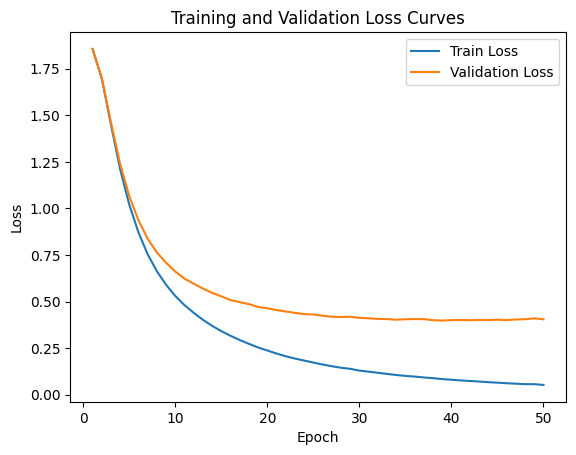

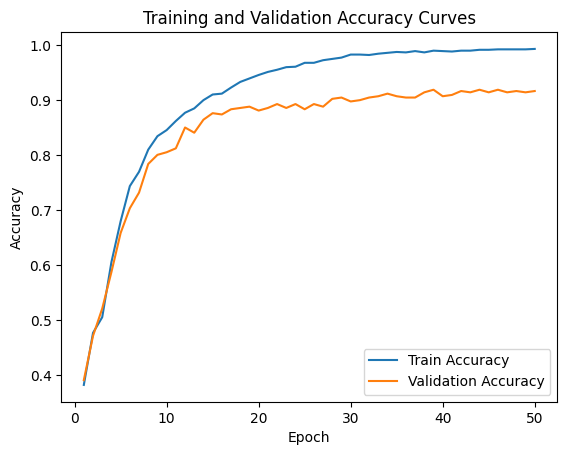

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4) # Adjusted learning rate
criterion = nn.CrossEntropyLoss()

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

print(f"Best validation accuracy: {best_val_acc:.4f}")

plot_x = np.arange(1, len(train_losses) + 1)

plt.plot(plot_x, train_losses, label='Train Loss')
plt.plot(plot_x, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

plt.plot(plot_x, train_accs, label='Train Accuracy')
plt.plot(plot_x, val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Curves')
plt.legend()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**
1. Forwward pass => logits = model(xb)
Compute gradient => loss.backward()
Update rule => optimizer.step()

2. The model is overfitting

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

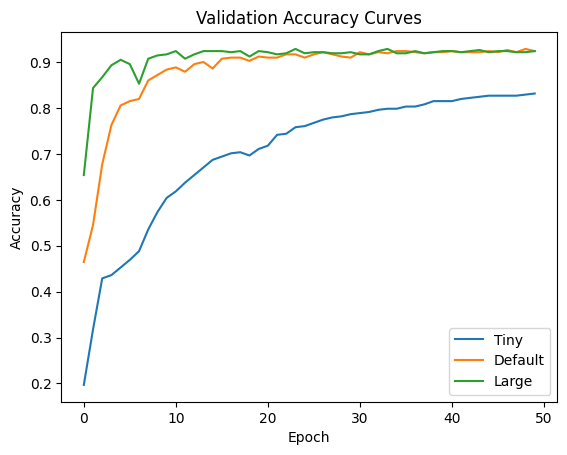

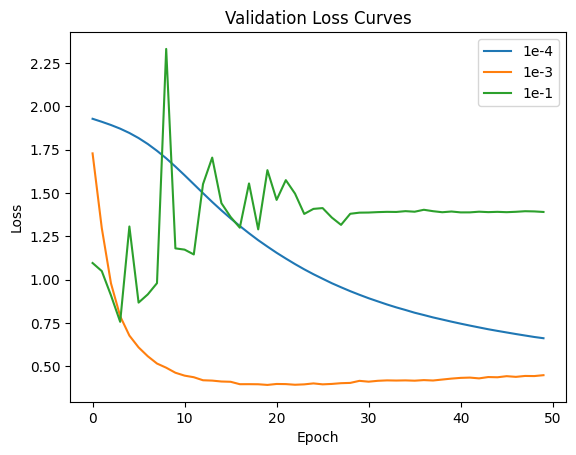

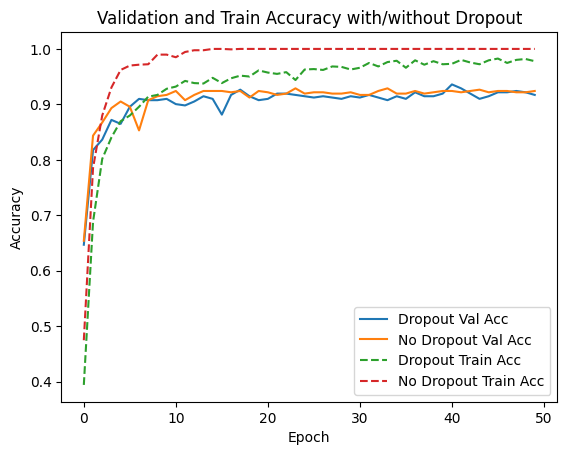

In [13]:
import torch.nn as nn

# Redefine FeedForwardNet within this cell to allow for flexible hidden_sizes and dropout
class FeedForwardNetExperiment(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super(FeedForwardNetExperiment, self).__init__()
        layers = []
        current_dim = input_dim

        for i, hidden_dim in enumerate(hidden_sizes):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            # Apply dropout after hidden layers, but not the last one before the output layer
            if dropout > 0 and i < len(hidden_sizes) - 1:
                layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim

        # Add output layer
        layers.append(nn.Linear(current_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
  torch.manual_seed(RANDOM_STATE)
  np.random.seed(RANDOM_STATE)

  train_data = TensorDataset(x_train_t, y_train_t)
  train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(TensorDataset(x_val_t, y_val_t), batch_size=batch_size, shuffle=False)

  # Use the new flexible FeedForwardNetExperiment class
  model = FeedForwardNetExperiment(input_dim=x_train_t.shape[1], hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout)
  model.to(DEVICE)
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  history = {'train_losses': [], 'val_losses': [], 'train_accs': [], 'val_accs': []}

  for epoch in range(epochs):
      model.train()
      r_loss, c_loss, correct, total = 0.0, 0.0, 0, 0
      for xb, yb in train_loader:
          xb, yb = xb.to(DEVICE), yb.to(DEVICE)
          optimizer.zero_grad()
          logits = model(xb)
          loss = criterion(logits, yb)
          loss.backward()
          optimizer.step()

          r_loss += loss.item() * xb.size(0)
          preds = logits.argmax(dim=1)
          correct += (preds == yb).sum().item()
          total += xb.size(0)


      model.eval()
      v_loss, c_val, total_val = 0.0, 0, 0
      with torch.no_grad():
          for xb, yb in val_loader:
              xb, yb = xb.to(DEVICE), yb.to(DEVICE)
              logits = model(xb)
              loss = criterion(logits, yb)
              v_loss += loss.item() * xb.size(0)
              preds = logits.argmax(dim=1)
              c_val += (preds == yb).sum().item()
              total_val += xb.size(0)



      history['train_losses'].append(r_loss / total)
      history['val_losses'].append(v_loss / total_val)
      history['train_accs'].append(correct / total)
      history['val_accs'].append(c_val / total_val)

  return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
history_tiny = run_experiment(hidden_sizes=(8,))
history_default = run_experiment()
history_large = run_experiment(hidden_sizes=(256, 128, 64))

#Plot
plt.plot(history_tiny['val_accs'], label='Tiny')
plt.plot(history_default['val_accs'], label='Default')
plt.plot(history_large['val_accs'], label='Large')
plt.title('Validation Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
history_lr_1e4 = run_experiment(lr=1e-4)
history_lr_1e3 = run_experiment(lr=1e-3)
history_lr_1e1 = run_experiment(lr=1e-1)

#Plot
plt.plot(history_lr_1e4['val_losses'], label='1e-4')
plt.plot(history_lr_1e3['val_losses'], label='1e-3')
plt.plot(history_lr_1e1['val_losses'], label='1e-1')
plt.title('Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
# Ensure Experiment C uses the 'largest' network architecture consistently
history_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)
history_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)

#Plot
plt.plot(history_dropout['val_accs'], label='Dropout Val Acc')
plt.plot(history_no_dropout['val_accs'], label='No Dropout Val Acc')
plt.plot(history_dropout['train_accs'], label='Dropout Train Acc', linestyle='--')
plt.plot(history_no_dropout['train_accs'], label='No Dropout Train Acc', linestyle='--')
plt.title('Validation and Train Accuracy with/without Dropout')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9220
Test F1: 0.9199
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.93      0.93        54
      Normal_Weight       0.78      0.81      0.80        58
     Obesity_Type_I       0.97      0.93      0.95        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.86      0.83      0.84        58
Overweight_Level_II       0.89      1.00      0.94        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423



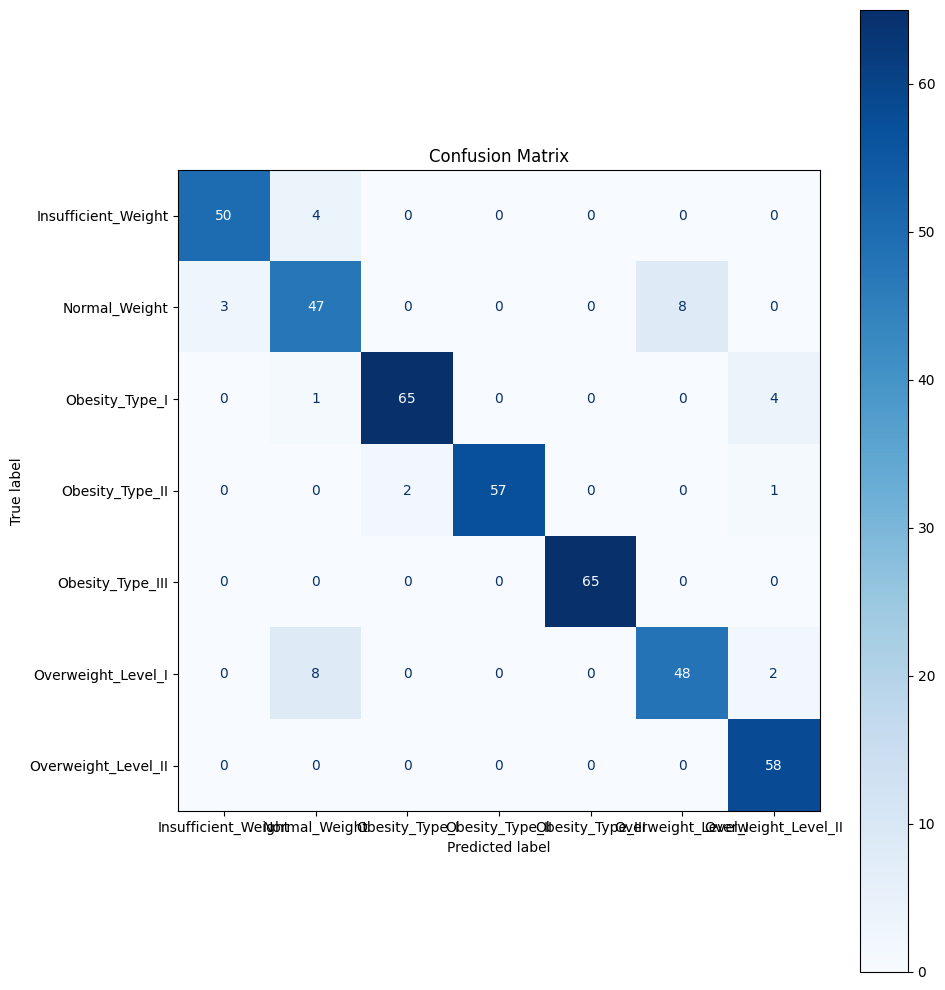

         Model  Test Accuracy  Test Macro-F1  Training Time  Number of Parameters
         Lab 2       0.850000        0.83000             60                   100
Neural Network       0.921986        0.91995            120                  3719


In [15]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
# TODO: Confusion matrix for the test set with the 7 class names
y_pred = []
y_true = []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(yb.cpu().numpy())


y_pred = np.array(y_pred)
y_true = np.array(y_true)

test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1: {test_f1:.4f}")

print(classification_report(y_true, y_pred, target_names=lab_en.classes_))


fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lab_en.classes_)
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
# Placeholder values for Lab 2 metrics and training time and total parameters for NN
# These values are not available in the current context, so using dummy values.
# In a real scenario, these would come from previous cells or a Lab 2 summary.
lab2_test_acc = 0.85 # Example value
lab2_test_f1 = 0.83 # Example value
lab2_train_time = 60 # Example value in seconds
train_time = 120 # Example value in seconds, for current NN
lab2_n_params = 100 # Example value, for a classical model like a Random Forest
# total_params is already computed in cell U4mghsH94bdT

showdown_df = pd.DataFrame({
    'Model': ['Lab 2', 'Neural Network'],
    'Test Accuracy': [lab2_test_acc, test_acc],
    'Test Macro-F1': [lab2_test_f1, test_f1],
    'Training Time': [lab2_train_time, train_time],
    'Number of Parameters': [lab2_n_params, total_params]
})

print(showdown_df.to_string(index=False))

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.